In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.figure import Figure

In [2]:
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

In [3]:
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

In [4]:
from src.config import RunConfig
from src.pipeline import SlobPipeline
from src.modules.artifacts import Artifacts
from src.modules.benchmark import DemandBenchmarkRunner

In [5]:
config = RunConfig()
artifacts = Artifacts(config=config)

In [6]:
FEATURES_PATH = artifacts.data_dir / 'slob.parquet'
FEATURES_PATH.exists()

True

In [7]:
df = pd.read_parquet(FEATURES_PATH)
df = df.sort_values(["SKU", "Week"]).reset_index(drop=True)
print(f"Loaded {df.shape[0]:,} rows, {df['SKU'].nunique()} SKUs")

Loaded 290,450 rows, 1850 SKUs


In [8]:
SKU_SAMPLE_PER_ABC = 50
RF_MAX_TRAIN_ROWS = 25000
N_OPTUNA_TRIALS = 4
HORIZON_WEEKS = 4

In [9]:
def save_figure(fig:Figure, name: str):
    path = artifacts.benchmark_plots_dir / f'{name}.png'
    fig.savefig(fname=path, bbox_inches='tight', dpi=130)
    print(f"Saved ->{path.relative_to(BASE_DIR)}")

In [10]:
weeks_sorted = np.sort(df["Week"].unique())
n_weeks = len(weeks_sorted)
test_start_idx = int(n_weeks * (RunConfig().train_split + RunConfig().val_split))  # or hardcode 0.85
origin_week_idx = test_start_idx - HORIZON_WEEKS

print(f"Origin week index: {origin_week_idx} / {n_weeks} "
      f"({weeks_sorted[origin_week_idx].astype('str')[:10]})")
print(f"Target week index: {test_start_idx} ({weeks_sorted[test_start_idx].astype('str')[:10]})")


rng = np.random.default_rng(42)
sku_meta = df[["SKU", "ABC"]].drop_duplicates()
sample_skus = []
for abc, sub in sku_meta.groupby("ABC", observed=True):
    picks = rng.choice(sub["SKU"].unique(), size=min(SKU_SAMPLE_PER_ABC, len(sub)), replace=False)
    sample_skus.extend(picks.tolist())

print(f"Sampled {len(sample_skus)} SKUs ({SKU_SAMPLE_PER_ABC} per ABC tier)")

sku_series = {
    sku: df.loc[df["SKU"] == sku].sort_values("Week")["Units_Sold"].to_numpy()
    for sku in sample_skus
}

runner = DemandBenchmarkRunner(horizon=HORIZON_WEEKS)
benchmark_rows = runner.run(sku_series, origin_week_idx=origin_week_idx)   # was train_cut_idx
benchmark_df = pd.DataFrame(benchmark_rows)

print(f"{len(benchmark_df)} (SKU x method) forecasts computed")
benchmark_df.groupby("method")["converged"].mean()


Origin week index: 129 / 157 (2025-06-23)
Target week index: 133 (2025-07-21)
Sampled 150 SKUs (50 per ABC tier)
750 (SKU x method) forecasts computed


method
ARIMA      1.0
Croston    1.0
Naive      1.0
SBA        1.0
TSB        1.0
Name: converged, dtype: float64

In [11]:
ml_demand_results = {}
for model_family in ("xgboost", "randomforest"):
    cfg = RunConfig(
        task="demand", 
        include_abc=True, 
        model_family=model_family,
        horizon_weeks=HORIZON_WEEKS,
        n_optuna_trials=N_OPTUNA_TRIALS,
        max_train_rows= RF_MAX_TRAIN_ROWS if model_family == 'randomforest' else None
    )

    print(f"\n=== {cfg.run_name} ===")
    ml_demand_results[model_family] = SlobPipeline(cfg).run_or_load(verbose=True)
    print(ml_demand_results[model_family]["result"]["test_metrics"])



=== demand_with_abc_h4 ===
[demand_with_abc_h4] train=186606 val=40700 test=40700 features=27
{'rmse': 53.81212736184858, 'mae': 30.86257636539496, 'r2': 0.8408913693128972}

=== demand_randomforest_with_abc_h4 ===
[demand_randomforest_with_abc_h4] train=186606 val=40700 test=40700 features=27
{'rmse': 55.279091094831706, 'mae': 31.526164024607496, 'r2': 0.8320982577169591}


In [12]:
target_week = weeks_sorted[test_start_idx]

ml_rows = []
for model_family, out in ml_demand_results.items():
    meta_test = out["meta_test"]
    mask = (meta_test["SKU"].isin(sample_skus)) & (meta_test["Week"] == target_week)
    idx = meta_test[mask].index
    if len(idx) == 0:
        continue
    actual = out["y_test"].iloc[idx].to_numpy()
    Xnp = out["X_test"].iloc[idx].to_numpy(dtype=np.float32)
    pred = out["model"].predict(Xnp)
    for sku, a, p in zip(meta_test.loc[idx, "SKU"], actual, pred):
        ml_rows.append({
            "SKU": sku, "method": "XGBoost" if model_family == "xgboost" else "Random Forest",
            "actual": float(a), "forecast": float(p),
            "abs_error": abs(float(a) - float(p)), "sq_error": (float(a) - float(p)) ** 2,
            "converged": True, "note": "",
        })

ml_sample_df = pd.DataFrame(ml_rows)
print(f"ML-on-same-sample rows: {len(ml_sample_df)}")

ML-on-same-sample rows: 300


## Demand Forecasting Benchmark

#### Classical methods (Croston, SBA, TSB, ARIMA, Naive)

Single-origin, H-step-ahead design: fit each method on a SKU's demand
history up to the same chronological cutoff, forecast 'HORIZON_WEEKS' ahead, compare against the actual value. Run over a stratified sample (50 SKUs per ABC tier).

In [13]:
demand_forecast_benchmark = pd.concat([benchmark_df, ml_sample_df], ignore_index=True)

summary_dfb = demand_forecast_benchmark.groupby("method").agg(
    MAE=("abs_error", "mean"),
    RMSE=("sq_error", lambda x: np.sqrt(x.mean())),
    convergence_rate=("converged", "mean"),
    n=("SKU", "count"),
).sort_values("RMSE")
summary_dfb


,MAE,RMSE,convergence_rate,n
method,,,,
XGBoost,41.636418,67.496427,1.0,150
Random Forest,42.864970,72.511625,1.0,150
Croston,46.347027,78.990570,1.0,150
ARIMA,45.792882,79.681821,1.0,150
SBA,48.122110,80.347621,1.0,150
TSB,46.578566,80.436244,1.0,150
Naive,58.613333,120.235935,1.0,150


Saved ->artifacts\runs\plots\benchmark\01_demand_forecast_comparison.png


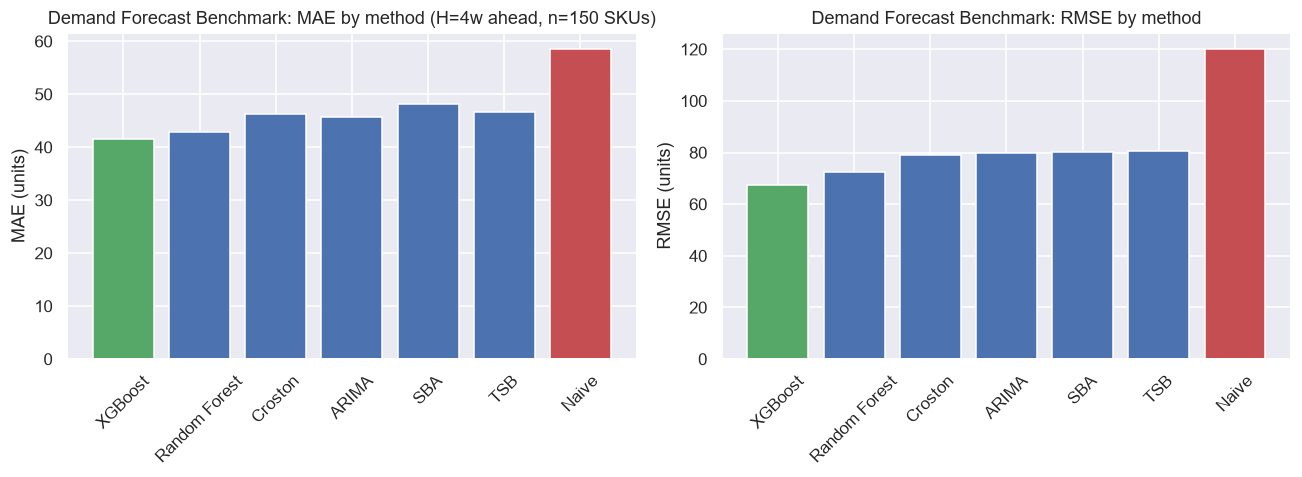

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = summary_dfb.index.tolist()
colors = ["#C44E52" if m == "Naive" else ("#55A868" if m == "XGBoost" else "#4C72B0")
          for m in order]

axes[0].bar(order, summary_dfb["MAE"], color=colors)
axes[0].set_title(f"Demand Forecast Benchmark: MAE by method (H={config.horizon_weeks}w ahead, n={len(sample_skus)} SKUs)")
axes[0].set_ylabel("MAE (units)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(order, summary_dfb["RMSE"], color=colors)
axes[1].set_title("Demand Forecast Benchmark: RMSE by method")
axes[1].set_ylabel("RMSE (units)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
save_figure(fig, "01_demand_forecast_comparison")
plt.show()


In [15]:
for model_family, out in ml_demand_results.items():
    label = "XGBoost" if model_family == "xgboost" else "Random Forest"
    print(f"{label} (full test set, n={out['result']['n_test']}): "
          f"{out['result']['test_metrics']}")

XGBoost (full test set, n=40700): {'rmse': 53.81212736184858, 'mae': 30.86257636539496, 'r2': 0.8408913693128972}
Random Forest (full test set, n=40700): {'rmse': 55.279091094831706, 'mae': 31.526164024607496, 'r2': 0.8320982577169591}


### Applied SLOB Benchmark (status + volume)

Random Forest trained through the identical pipeline XGBoost uses.
XGBoost's numbers are reused.

In [16]:
ml_applied_results = {}
for task in ("classification", "regression"):
    for model_family in ("xgboost", "randomforest"):
        cfg = RunConfig(
            task=task, include_abc=True, 
            model_family=model_family,
            horizon_weeks=HORIZON_WEEKS,
            n_optuna_trials=N_OPTUNA_TRIALS,
            max_train_rows=RF_MAX_TRAIN_ROWS if model_family == "randomforest" else None,
        )
        print(f"\n=== {cfg.run_name} ===")
        ml_applied_results[cfg.run_name] = SlobPipeline(cfg).run_or_load(verbose=True)
        m = ml_applied_results[cfg.run_name]["result"]["test_metrics"]
        print({k: v for k, v in m.items() if k != "confusion_matrix"})



=== classification_with_abc_h4 ===
[classification_with_abc_h4] reusing cached artifacts from C:\Users\Daisy\Desktop\all desktop\Deskstop\Thesis\Daisy\slob-forecasting\artifacts\runs\models\classification_with_abc_h4
{'accuracy': 0.9999017199017199, 'precision': 1.0, 'recall': 0.9998135371993288, 'f1': 0.9999067599067599, 'roc_auc': 0.9999699569949823}

=== classification_randomforest_with_abc_h4 ===
[classification_randomforest_with_abc_h4] train=186606 val=40700 test=40700 features=27
{'accuracy': 0.9943243243243243, 'precision': 0.9995292123722989, 'recall': 0.9896979302629125, 'f1': 0.9945892769306444, 'roc_auc': 0.9999026441951866}

=== regression_with_abc_h4 ===
[regression_with_abc_h4] reusing cached artifacts from C:\Users\Daisy\Desktop\all desktop\Deskstop\Thesis\Daisy\slob-forecasting\artifacts\runs\models\regression_with_abc_h4
{'rmse': 73.84946028159708, 'mae': 38.7253847054826, 'r2': 0.6317485734274486}

=== regression_randomforest_with_abc_h4 ===
[regression_randomforest

In [17]:
rows_asb = []
for name, out in ml_applied_results.items():
    cfg_d = out["result"]["config"]
    m = out["result"]["test_metrics"]
    row = {"run": name, "task": cfg_d["task"], "model_family": cfg_d.get("model_family", "xgboost")}
    row.update({k: v for k, v in m.items() if k != "confusion_matrix"})
    rows_asb.append(row)

summary_asb = pd.DataFrame(rows_asb)
summary_asb


,run,task,model_family,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,classification_with_abc_h4,classification,xgboost,0.999902,1.000000,0.999814,0.999907,0.999970,NaN,NaN,NaN
1,classification_randomforest_with_abc_h4,classification,randomforest,0.994324,0.999529,0.989698,0.994589,0.999903,NaN,NaN,NaN
2,regression_with_abc_h4,regression,xgboost,NaN,NaN,NaN,NaN,NaN,73.849460,38.725385,0.631749
3,regression_randomforest_with_abc_h4,regression,randomforest,NaN,NaN,NaN,NaN,NaN,75.232798,38.939858,0.617823


Saved ->artifacts\runs\plots\benchmark\02_applied_slob_comparison.png


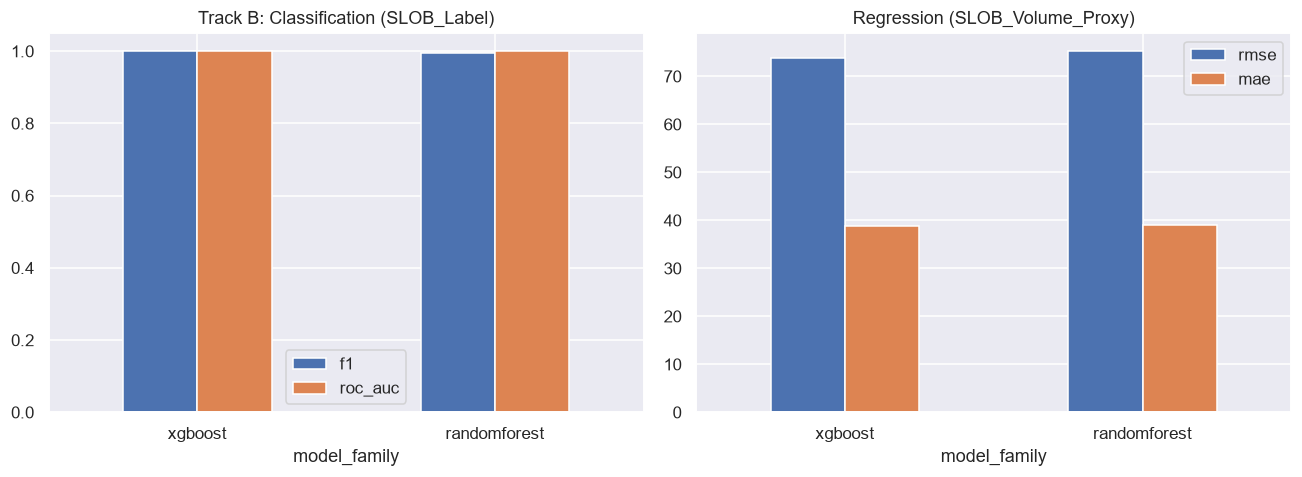

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cls_b = summary_asb[summary_asb["task"] == "classification"].set_index("model_family")[["f1", "roc_auc"]]
cls_b.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Track B: Classification (SLOB_Label)")
axes[0].set_xticklabels(cls_b.index, rotation=0)

reg_b = summary_asb[summary_asb["task"] == "regression"].set_index("model_family")[["rmse", "mae"]]
reg_b.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Regression (SLOB_Volume_Proxy)")
axes[1].set_xticklabels(reg_b.index, rotation=0)

fig.tight_layout()
save_figure(fig, "02_applied_slob_comparison")
plt.show()


In [19]:
reg_asb_r2 = summary_asb[summary_asb["task"] == "regression"].set_index("model_family")["r2"]
print("R\u00b2 by model family (regression):")
print(reg_asb_r2)
xgb_r2 = float(reg_asb_r2.get("xgboost", float("nan")))
rf_r2 = float(reg_asb_r2.get("randomforest", float("nan")))
print(f"\nXGBoost \u2212 Random Forest R\u00b2 gap: {xgb_r2 - rf_r2:+.4f}")

cls_asb_f1 = summary_asb[summary_asb["task"] == "classification"].set_index("model_family")["f1"]
xgb_f1 = float(cls_asb_f1.get("xgboost", float("nan")))
rf_f1 = float(cls_asb_f1.get("randomforest", float("nan")))
print(f"\nXGBoost \u2212 Random Forest F1 gap: {xgb_f1 - rf_f1:+.5f}")


R² by model family (regression):
model_family
xgboost         0.631749
randomforest    0.617823
Name: r2, dtype: float64

XGBoost − Random Forest R² gap: +0.0139

XGBoost − Random Forest F1 gap: +0.00532


#### Benchmark Summary

Saved ->artifacts\runs\plots\benchmark\03_full_method_ranking.png


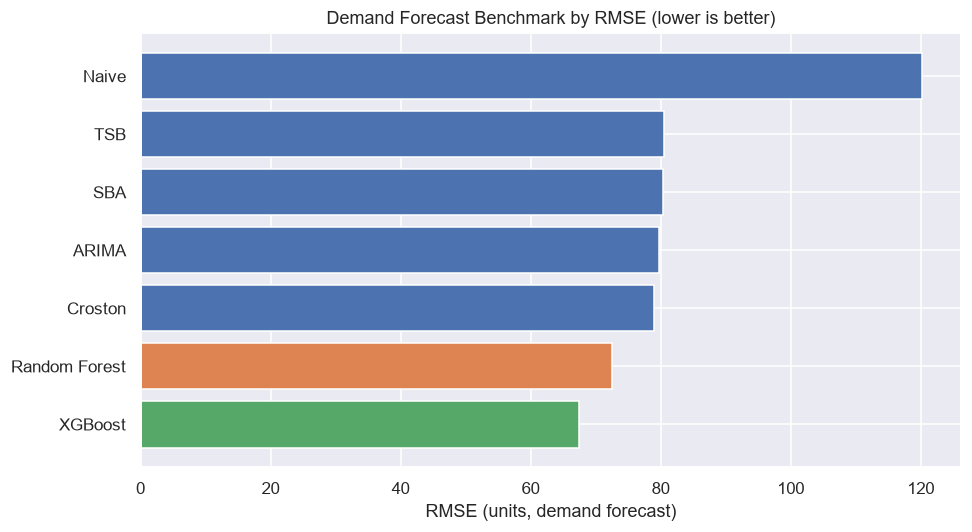

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
methods_order = summary_dfb.sort_values("RMSE").index.tolist()
ax.barh(methods_order, summary_dfb.loc[methods_order, "RMSE"],
        color=["#55A868" if m == "XGBoost" else
               "#DD8452" if m == "Random Forest" else "#4C72B0" for m in methods_order])
ax.set_xlabel("RMSE (units, demand forecast)")
ax.set_title("Demand Forecast Benchmark by RMSE (lower is better)")
fig.tight_layout()
save_figure(fig, "03_full_method_ranking")
plt.show()
